# ISYE 6644 Project - *Pandemic Flu Spread*

### Group 102

Blake French | Hande Pehlivan | Teemu Kettunen

The base scenario.

This was written with python 3.6.8. and the following library versions were used:
* numpy==1.18.0
* pandas==1.1.5
* matplotlib==3.0.2
* seaborn==0.11.2

In [1]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
sns.set()

In [2]:
# Simulation constants
num_kids = 21  # including Tommy
chance_of_infection = 0.02
num_days_contagious = 3
num_days = 30
num_iterations = 100000

In [3]:
result = np.zeros((1, num_days))

In [4]:
# create base num_days by num_kids matrix of zeros
# column zero is Tommy, row zero is baseline
# Each kid is represented by a number 0-4, where:
  # 0 is non-infected
  # 1-3 is the number of days infected
  # 4 is post infection
def init_matrix():
    
    base_m = np.zeros((num_days+1, num_kids))

    # first column is Tommy who is sick for first num_days_contagious days
    for i, day in enumerate(range(num_days_contagious)):
      base_m[day, 0] = i+1

    # once he gets better he cannot be re-infected so use 4
    base_m[num_days_contagious:(num_days+1), 0] = 4
    return base_m

In [7]:
# to model the N day cycle we need to loop thru and infect kids

result = np.zeros((num_iterations, num_days+1))
result_total = np.zeros((num_iterations, num_days+1))
result_w_tommy = np.zeros((num_iterations, num_days+1))

random.seed (a=123456789)

for t in range(num_iterations):
    base_m = init_matrix()

    for day in range(num_days):
        for kid in range(num_kids):

            # if not infected, see if they will be
            if base_m[day, kid] == 0:
                # Base case with just Tommy infecting other kids. This sim should only last 3 days
                # if random.random() < chance_of_infection:
                #     base_m[day, kid] = 1
                # else:
                #     base_m[day, kid] = 0
            
                # Case when any infected kid will infect others for 3 days
                # if they have not been infected, iterate thru each infected kid
                # and see if infection occurs
                for k in base_m[day,]:
                    # python's random generator: https://docs.python.org/3/library/random.html
                    if k in range(1, 4) and random.random() < chance_of_infection:
                        base_m[day+1, kid] = 1

            elif base_m[day, kid] in range(1, 3):
                base_m[day+1, kid] = base_m[day, kid] + 1

            else:
                base_m[day+1, kid] = 4
 
    # add daily result to result matrix
    for day in range(num_days):
        result[t, day] = np.count_nonzero(base_m[day+1,] == 1 ) 
    
    # add daily result (all infeced) to result_total matrix
    for day in range(num_days):
        result_total[t, day] = np.count_nonzero(np.logical_and(base_m[day+1,1:]>= 1, base_m[day+1,1:]<= 3))

    # add daily result (all infeced) to result_total matrix
    for day in range(num_days):
        result_w_tommy[t, day] = np.count_nonzero(np.logical_and(base_m[day+1,]>= 1, base_m[day+1,]<= 3)) 

    # Store the total num of infections for the day in the last column
    result[t, num_days] = np.sum(result[t,0:(num_days-1)])
    
    result_total[t, num_days] = np.sum(result_total[t,0:(num_days-1)])
    
    result_w_tommy[t, num_days] = np.sum(result_w_tommy[t,0:(num_days-1)])

In [8]:
# skim thru result
print(result)
print(result_total)

print(np.count_nonzero(result_total[0: ,0]))
#print(len(result_total[0: ,0]))

[[ 0.  1.  0. ...  0.  0.  1.]
 [ 1.  1.  3. ...  0.  0. 15.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [ 0.  2.  0. ...  0.  0. 10.]
 [ 1.  1.  2. ...  0.  0. 11.]
 [ 0.  0.  0. ...  0.  0.  0.]]
[[ 0.  1.  1. ...  0.  0.  3.]
 [ 1.  2.  5. ...  0.  0. 45.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [ 0.  2.  2. ...  0.  0. 30.]
 [ 1.  2.  4. ...  0.  0. 33.]
 [ 0.  0.  0. ...  0.  0.  0.]]
33205


In [9]:
# create dataframe for results(new infections) and result_total (number currently infected) 
cols = [f'day{n}' for n in range(1,num_days+1)] + ['total']
result_df = pd.DataFrame(result, columns=cols)
result_df.describe()


,day1,day2,day3,day4,day5,day6,day7,day8,day9,day10,...,day22,day23,day24,day25,day26,day27,day28,day29,day30,total
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.398110,0.538900,0.703620,0.540200,0.538980,0.496390,0.396650,0.32922,0.264780,0.200500,...,0.001340,0.000820,0.00049,0.000340,0.000120,0.000060,0.000050,0.000020,0.000010,4.914880
std,0.623492,0.752962,0.878434,0.853212,0.864921,0.836358,0.750469,0.68044,0.612565,0.530153,...,0.040227,0.029314,0.02387,0.019997,0.010954,0.008944,0.008366,0.004472,0.003162,5.243797
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000
max,6.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,6.00000,7.000000,8.000000,...,3.000000,2.000000,2.00000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000,20.000000


In [10]:
# create dataframe for result_total (number currently infected) 
cols = [f'day{n}' for n in range(1,num_days+1)] + ['total']
result_total_df = pd.DataFrame(result_total, columns=cols)
result_total_df.describe()

,day1,day2,day3,day4,day5,day6,day7,day8,day9,day10,...,day22,day23,day24,day25,day26,day27,day28,day29,day30,total
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.398110,0.937010,1.640630,1.782720,1.782800,1.575570,1.432020,1.222260,0.990650,0.79450,...,0.008550,0.004950,0.002650,0.001650,0.000950,0.000520,0.000230,0.000130,0.000080,14.744550
std,0.623492,1.103419,1.647796,1.907592,2.049162,2.014902,1.942137,1.793849,1.606128,1.42964,...,0.124968,0.090805,0.066506,0.050866,0.040114,0.028631,0.018165,0.015165,0.012649,15.731208
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000
75%,1.000000,1.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,2.000000,1.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.000000
max,6.000000,10.000000,13.000000,15.000000,16.000000,13.000000,13.000000,13.000000,12.000000,12.00000,...,5.000000,5.000000,4.000000,4.000000,4.000000,3.000000,2.000000,3.000000,3.000000,60.000000


In [11]:
# create dataframe for result_total (number currently infected) 
cols = [f'day{n}' for n in range(1,num_days+1)] + ['total']
result_w_tommy_df = pd.DataFrame(result_w_tommy, columns=cols)
result_w_tommy_df.describe()

,day1,day2,day3,day4,day5,day6,day7,day8,day9,day10,...,day22,day23,day24,day25,day26,day27,day28,day29,day30,total
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.398110,1.937010,1.640630,1.782720,1.782800,1.575570,1.432020,1.222260,0.990650,0.79450,...,0.008550,0.004950,0.002650,0.001650,0.000950,0.000520,0.000230,0.000130,0.000080,16.744550
std,0.623492,1.103419,1.647796,1.907592,2.049162,2.014902,1.942137,1.793849,1.606128,1.42964,...,0.124968,0.090805,0.066506,0.050866,0.040114,0.028631,0.018165,0.015165,0.012649,15.731208
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000
75%,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,2.000000,1.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000
max,7.000000,11.000000,13.000000,15.000000,16.000000,13.000000,13.000000,13.000000,12.000000,12.00000,...,5.000000,5.000000,4.000000,4.000000,4.000000,3.000000,2.000000,3.000000,3.000000,62.000000


In [12]:
# Summarize results
summary = result.mean(axis=0)
summary_df = pd.DataFrame(summary.reshape(1, (num_days+1)), columns=cols)
summary_df.head()

,day1,day2,day3,day4,day5,day6,day7,day8,day9,day10,...,day22,day23,day24,day25,day26,day27,day28,day29,day30,total
0,0.39811,0.5389,0.70362,0.5402,0.53898,0.49639,0.39665,0.32922,0.26478,0.2005,...,0.00134,0.00082,0.00049,0.00034,0.00012,0.00006,0.00005,0.00002,0.00001,4.91488


In [13]:
summary_total = result_total.mean(axis=0)
summary_total_df = pd.DataFrame(summary_total.reshape(1, (num_days+1)), columns=cols)
summary_total_df.head()

,day1,day2,day3,day4,day5,day6,day7,day8,day9,day10,...,day22,day23,day24,day25,day26,day27,day28,day29,day30,total
0,0.39811,0.93701,1.64063,1.78272,1.7828,1.57557,1.43202,1.22226,0.99065,0.7945,...,0.00855,0.00495,0.00265,0.00165,0.00095,0.00052,0.00023,0.00013,0.00008,14.74455


In [14]:
summary_w_tommy = result_w_tommy.mean(axis=0)
summary_w_tommy_df = pd.DataFrame(summary_w_tommy.reshape(1, (num_days+1)), columns=cols)
summary_w_tommy_df.head()

,day1,day2,day3,day4,day5,day6,day7,day8,day9,day10,...,day22,day23,day24,day25,day26,day27,day28,day29,day30,total
0,1.39811,1.93701,1.64063,1.78272,1.7828,1.57557,1.43202,1.22226,0.99065,0.7945,...,0.00855,0.00495,0.00265,0.00165,0.00095,0.00052,0.00023,0.00013,0.00008,16.74455


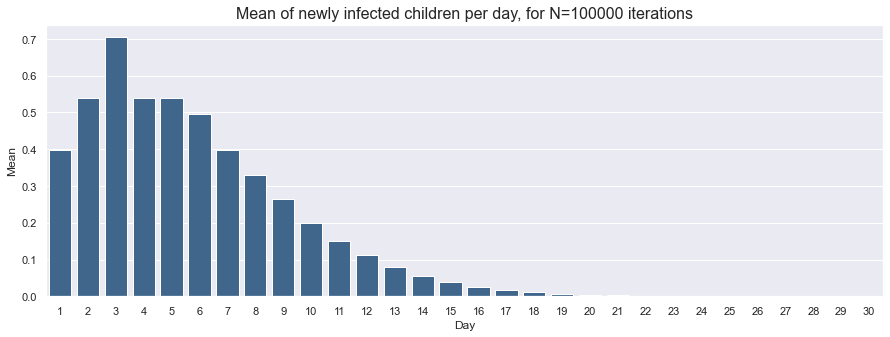

In [15]:
# Plot the distribution
fig, ax = plt.subplots(figsize=(15,5))
sns.barplot(x=list(range(1,num_days+1)), y=summary[:num_days], ax=ax, color=(0.2, 0.4, 0.6, 1))
ax.set_xlabel('Day')
ax.set_ylabel('Mean')
ax.set_title(f'Mean of newly infected children per day, for N={num_iterations} iterations', fontsize=16)
plt.show()

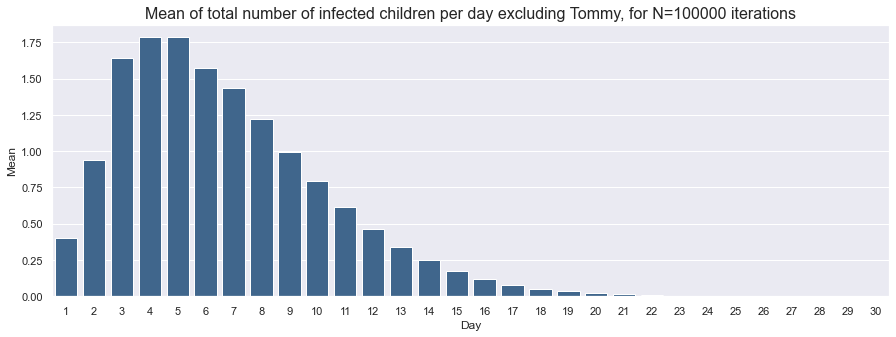

In [16]:
# Plot the distribution
fig, ax = plt.subplots(figsize=(15,5))
sns.barplot(x=list(range(1,num_days+1)), y=summary_total[:num_days], ax=ax, color=(0.2, 0.4, 0.6, 1))
ax.set_xlabel('Day')
ax.set_ylabel('Mean')
ax.set_title(f'Mean of total number of infected children per day excluding Tommy, for N={num_iterations} iterations', fontsize=16)
plt.show()

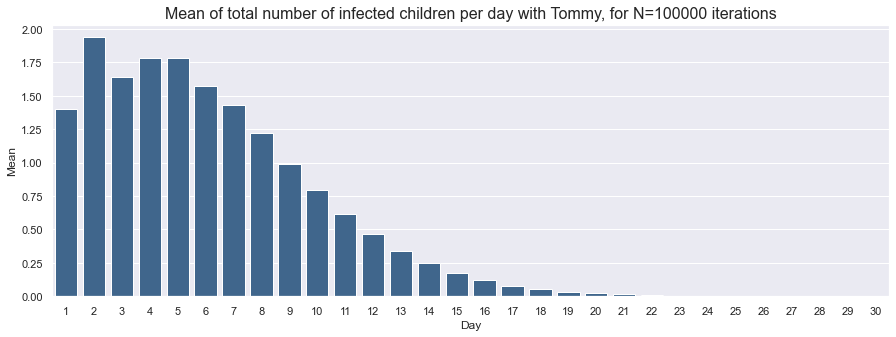

In [17]:
# Plot the distribution
fig, ax = plt.subplots(figsize=(15,5))
sns.barplot(x=list(range(1,num_days+1)), y=summary_w_tommy[:num_days], ax=ax, color=(0.2, 0.4, 0.6, 1))
ax.set_xlabel('Day')
ax.set_ylabel('Mean')
ax.set_title(f'Mean of total number of infected children per day with Tommy, for N={num_iterations} iterations', fontsize=16)
plt.show()

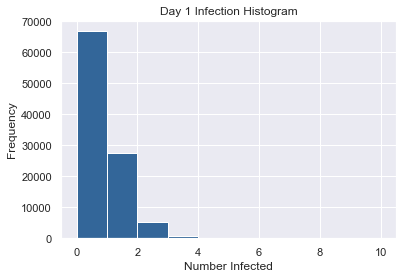

In [46]:
# Summarize results
#result_df['day1']

hist = result_df.hist(column='day1', bins=[0,1,2,3,4,5,6,7,8,9,10], color=(0.2, 0.4, 0.6, 1))
for ax in hist.flatten():
    ax.set_xlabel("Number Infected")
    ax.set_ylabel("Frequency")  
    ax.set_title("Day 1 Infection Histogram")

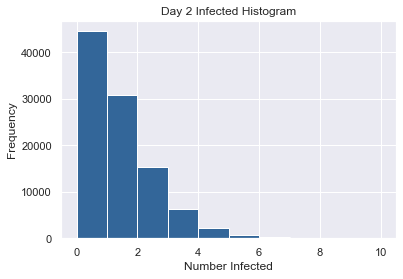

In [53]:
# day 2 total infected

#hist = result_total_df.hist(column='day2', bins=[0,1,2,3,4,5,6,7,8,9,10], color=(0.2, 0.4, 0.6, 1))

hist = result_total_df.hist(column='day2', bins=[0,1,2,3,4,5,6,7,8,9,10], color=(0.2, 0.4, 0.6, 1))
for ax in hist.flatten():
    ax.set_xlabel("Number Infected")
    ax.set_ylabel("Frequency")  
    ax.set_title("Day 2 Infected Histogram")

In [54]:
#result = np.where(nums == 0)[0]
#print(result_total[ 0:, 0:30])

duration = np.zeros(num_iterations)

i=0
for r in result_total[ 0:, 0:30]:
    #duration[i] =np.where( r == 0 )[0][0]
    ind = np.where( np.flip(r) > 0 )
    if ind[0].size == 0:
        duration[i] = 0
    else:
        duration[i] = 30 - ind[0][0]
    i+=1




In [55]:
duration_df = pd.DataFrame(duration, columns=['num_days'])
duration_df.describe()

,num_days
count,100000.00000
mean,6.60649
std,5.68075
min,0.00000
25%,0.00000
50%,6.00000
75%,11.00000
max,30.00000


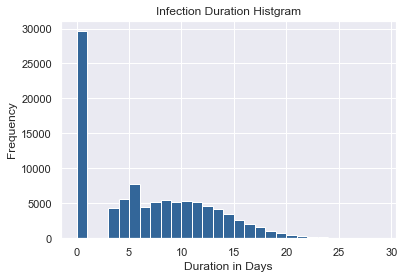

In [59]:

#hist = duration_df.hist(column='num_days', bins=range(30), color=(0.2, 0.4, 0.6, 1))

hist = duration_df.hist(column='num_days', bins=range(30), color=(0.2, 0.4, 0.6, 1))
for ax in hist.flatten():
    ax.set_xlabel("Duration in Days")
    ax.set_ylabel("Frequency")  
    ax.set_title("Infection Duration Histgram")

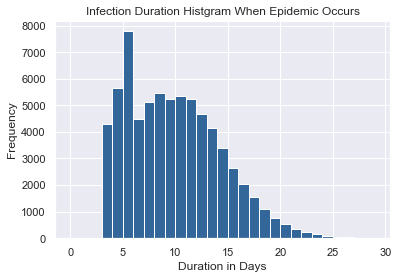

In [65]:
duration_df2 = duration_df[duration_df.num_days > 0]
hist = duration_df2.hist(column='num_days', bins=range(30), color=(0.2, 0.4, 0.6, 1))
for ax in hist.flatten():
    ax.set_xlabel("Duration in Days")
    ax.set_ylabel("Frequency")  
    ax.set_title("Infection Duration Histgram When Epidemic Occurs")

In [66]:
duration_df2.describe()

,num_days
count,70380.000000
mean,9.386885
std,4.444432
min,3.000000
25%,5.000000
50%,9.000000
75%,12.000000
max,30.000000


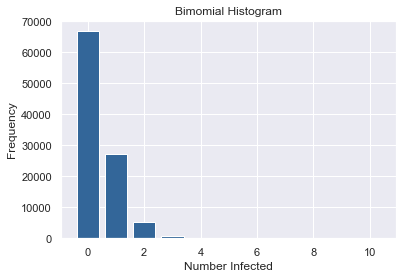

In [67]:
#plotting binomial 
from scipy.stats import binom
import matplotlib.pyplot as plt
# setting the values
# of n and p
n = 20
p = 0.02
# defining list of r values
r_values = list(range(11))
# list of pmf values
dist = [binom.pmf(r, n, p)*100000 for r in r_values ]
# plotting the graph 

fig, ax = plt.subplots()
plt.bar(r_values, dist, color=(0.2, 0.4, 0.6, 1))
ax.set_xlabel("Number Infected")
ax.set_ylabel("Frequency")  
ax.set_title("Bimomial Histogram")
plt.show()



In [72]:
num_kids = 20  # including Tommy
chance_of_infection = 0.02
num_days_contagious = 3
num_days = 30
num_iterations = 10000

Text(0, 0.5, 'Population')

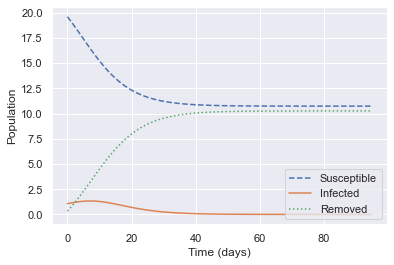

In [73]:

tc= 1 # students contact each other only weekdays

beta =  chance_of_infection #*(21/tc)
gamma = 1/num_days_contagious 

# Initial condition
S_initals = 20
I_initals = 1
R_initals = 0
S=[]
I=[]
R=[]

def SIR_simu(S_initals,I_initals,R_initals,gamma,beta):
    Infected = beta*I_initals*S_initals
    Removed = gamma*I_initals

    S = S_initals - Infected
    I = I_initals +Infected - Removed
    R = R_initals + Removed
    s=[S,]
    i=[I,]
    r=[R,]
    
# Step equations forward in time
    n=0
    tot_SIR=1  # Why do
    while n < 95:
        for t in range(0,95):
            S_ = s[t] - tot_SIR*beta*s[t]*i[t]
            I_ = i[t] + tot_SIR*beta*s[t]*i[t] - gamma*i[t]
            R_ = r[t] +  gamma*i[t]
            s.append(S_)
            i.append(I_)
            r.append(R_)
            n +=1
    return s,i,r

S, I, R = SIR_simu(20,1,0,gamma,beta)
plt.plot(S, '--', label='Susceptible')
plt.plot(I, '-', label='Infected')
plt.plot(R, ':', label='Removed')
plt.legend(['Susceptible', 'Infected','Removed'],loc="lower right")
plt.xlabel('Time (days)'),
plt.ylabel('Population')

from numpy import zeros, linspace
import matplotlib.pyplot as plt

# Time unit: 1 h
beta = 0.02 # 0.9375 new infections in 2 days 
gamma = 1./(3)
dt = 1             # 1 day
D = 30               # Simulate for D days
N_t = int(D/dt)   # Corresponding no days

t = linspace(0, N_t*dt, N_t+1)
S = zeros(N_t+1)
I = zeros(N_t+1)
R = zeros(N_t+1)

# Initial condition
S[0] = 20
I[0] = 1
R[0] = 0

# Step equations forward in time
for n in range(N_t):
    S[n+1] = S[n] - dt*beta*S[n]*I[n]
    I[n+1] = I[n] + dt*beta*S[n]*I[n] - dt*gamma*I[n]
    R[n+1] = R[n] + dt*gamma*I[n]


            
fig = plt.figure()
l1, l2, l3 = plt.plot(t, S, t, I, t, R)
fig.legend((l1, l2, l3), ('S', 'I', 'R'), 'upper left')
plt.xlabel('days')
plt.show()

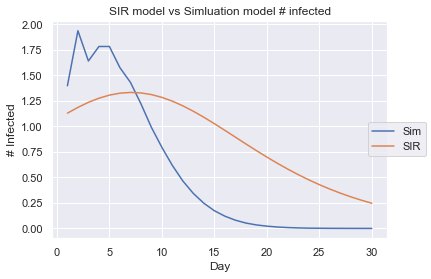

In [77]:
fig= plt.figure()
l1, l2 = plt.plot(list(range(1,num_days+1)), summary_w_tommy[0:30], list(range(1,num_days+1)), I[1:31],)
fig.legend((l1, l2), ('Sim', 'SIR',), 'right')
plt.xlabel('days')
plt.title('SIR model vs Simluation model # infected')

plt.xlabel("Day")
plt.ylabel("# Infected")
plt.show()